In this notebook, the results from the simple dynamical system in one dimension from Hiroshi Serizawa, Takashi Amemiya, and Kiminori Itoh. “Patchiness in a minimal
nutrient—phytoplankton model”. In: Journal of Biosciences 33.3 (2008), pp. 391–403. will be replicated.

Important quantities used throughout (Table 1 in the paper):
- N: Nutrient concentration
- P: Plankton density
- T: time
- $I_N$: Input rate of nutrient
- $\mu$: Maximum growth rate of phytoplankton
- $k$: Nutrient content in phytoplankton
- $m_N$: Loss rate of nutrient
- $f_P$: Maximum feeding rate of zooplankton on
phytoplankton
- $H_N$: Half-saturation constant of nutrient
- $H_p$: Half-saturation constant of phytoplankton

Using dimensionless parameters the variables and parameters that will be used in the code are:
- $t = \mu t$
- $n = N\times H_N^{-1}$
- $p = P\times H_P^{-1}$
- $i_n = I_N\times\mu^{-1}\times H_N^{-1}$
- $a = k\times H_P\times H_N^{-1}$
- $m_n = m_N \times\mu^{-1}$
- $f_p = f_P \times\mu^{-1}\times H_P^{-1}$
- $d$: Diffussion coefficient
- $\nu_{max}$: Maximum velocity
- $L$: Half length of square domain side
- $A$: Scale factor for initial distributions of n and p

The system with these variables will be:
\begin{aligned}
\dfrac{dn}{dt} &= i_n - a \dfrac{n}{n+1}p - m_nn\\
\dfrac{dp}{dt} &= \dfrac{n}{n+1}p - f_p\dfrac{p}{1+p}
\end{aligned}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

/home/alonso/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
'''Function that implements the instantaneous rate of change for the nutrient availability with dimensionless variables'''
def dn(n, p, i_n, a, m_n):
    
    return i_n - a*n/(1 + n)*p - m_n*n

In [3]:
'''Function that implements the instantaneous rateof change of the dimensionless phytoplankton density'''
def dp(n, p, f_p):
    
    return n/(1 + n)*p - f_p*p*(1 + p)

In [4]:
'''Function to solve the system of equations using euler's method'''
def solve_system_euler(n_0, p_0, dt, T, i_n, a, m_n, f_p):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)

    n = [n_0]
    p = [p_0]

    for _ in range(n_iter):

        prev_n = n[-1]
        prev_p = p[-1]

        new_n = prev_n + dt*(dn(prev_n, prev_p, i_n, a, m_n))
        new_p = prev_p + dt*(dp(prev_n, prev_p, f_p))

        n.append(new_n)
        p.append(new_p)

    return t_interval, n, p

In [5]:
'''Function to solve the system of equations using RK4'''
def solve_system_rk4(n_0, p_0, dt, T, i_n, a, m_n, f_p):

    n_iter = int(T//dt)
    t_interval = np.linspace(0,T,n_iter+1)
    
    n = [n_0]
    p = [p_0]

    for _ in range(n_iter):

        prev_n = n[-1]
        prev_p = p[-1]

        k1_n = dn(prev_n, prev_p, i_n, a, m_n)
        k1_p = dp(prev_n, prev_p, f_p)

        k2_n = dn(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2,i_n, a, m_n)
        k2_p = dp(prev_n + k1_n*dt/2, prev_p + k1_p*dt/2, f_p)

        k3_n = dn(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2,i_n, a, m_n)
        k3_p = dp(prev_n + k2_n*dt/2, prev_p + k2_p*dt/2, f_p)

        k4_n = dn(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2,i_n, a, m_n)
        k4_p = dp(prev_n + k3_n*dt/2, prev_p + k3_p*dt/2, f_p)

        new_n = prev_n + (k1_n + 2*k2_n + 2*k3_n + k4_n)*dt/6
        new_p = prev_p + (k1_p + 2*k2_p + 2*k3_p + k4_p)*dt/6

        n.append(new_n)
        p.append(new_p)

    return t_interval, n, p


In [6]:
# Set 1
n_0 = 5
p_0 = 0.2
i_n = 0.9
a = 8
m_n = 0.03
f_p = 0.9
T = 1000
dt = 0.12

In [7]:
t, n, p = solve_system_rk4(n_0, p_0, dt, T, i_n, a, m_n, f_p)

In [8]:
n_0 = i_n/m_n#*np.ones_like(t)
n_1 = (i_n - m_n + a*(1-f_p) + np.sqrt((m_n + a*(f_p-1) - i_n)**2 - 4*m_n*(a*f_p-i_n)))/(2*m_n)#*np.ones_like(t)
n_2 = (i_n - m_n + a*(1-f_p) - np.sqrt((m_n + a*(f_p-1) - i_n)**2 - 4*m_n*(a*f_p-i_n)))/(2*m_n)#*np.ones_like(t)

p_1 = f_p/n_1 + f_p - 1
p_2 = f_p/n_2 + f_p - 1

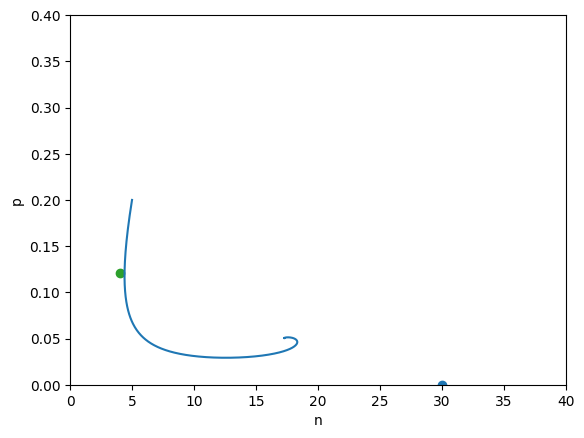

In [9]:
plt.plot(n, p)
plt.scatter(n_0, 0)
plt.scatter(n_1, p_1)
plt.scatter(n_2, p_2)
plt.xlim(0,40)
plt.ylim(0,0.4)
plt.xlabel('n')
plt.ylabel('p')
plt.show()

In [10]:
# Set 2
n_0 = 2.5
p_0 = 0.4
i_n = 1.8
a = 8
m_n = 0.03
f_p = 1
T = 1000
dt = 0.12

In [11]:
t, n, p = solve_system_rk4(n_0, p_0, dt, T, i_n, a, m_n, f_p)

In [12]:
n_0 = i_n/m_n#*np.ones_like(t)
n_1 = (i_n - m_n + a*(1-f_p) + np.sqrt((m_n + a*(f_p-1) - i_n)**2 - 4*m_n*(a*f_p-i_n)))/(2*m_n)#*np.ones_like(t)
n_2 = (i_n - m_n + a*(1-f_p) - np.sqrt((m_n + a*(f_p-1) - i_n)**2 - 4*m_n*(a*f_p-i_n)))/(2*m_n)#*np.ones_like(t)

p_1 = f_p/n_1 + f_p - 1
p_2 = f_p/n_2 + f_p - 1

print(f'F0 =({n_0:.3f}, 0)')
print(f'F1 =({n_1:.3f}, {p_1:.3f})')
print(f'F2 =({n_2:.3f}, {p_2:.3f})')

F0 =(60.000, 0)
F1 =(55.260, 0.018)
F2 =(3.740, 0.267)


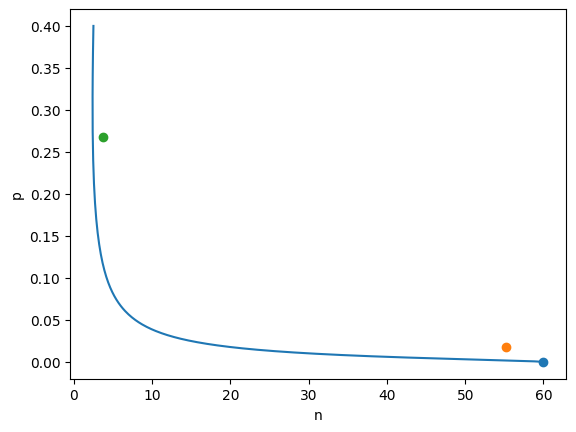

In [13]:
plt.plot(n, p)
plt.scatter(n_0, 0)
plt.scatter(n_1, p_1)
plt.scatter(n_2, p_2)
plt.xlabel('n')
plt.ylabel('p')
#plt.xlim(0,40)
#plt.ylim(0,0.4)
plt.show()